## Carbon Footprint AI - Exploratory Data Analysis

**Project**: Carbon Footprint AI Microservice  
**Dataset**: ASHRAE - Great Energy Predictor III  
**Date**: November 2025  

---

## Objectives

This notebook performs exploratory data analysis on the ASHRAE energy consumption dataset:

1. **Load and inspect the datasets** (building metadata, meter readings, weather data)
2. **Understand data structure and types**
3. **Identify missing values and data quality issues**
4. **Analyze distributions and patterns**
5. **Explore correlations between features**
6. **Generate insights for carbon emission prediction**

---

## 1. Setup & Imports

In [26]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis

# Utilities
import warnings
from datetime import datetime
import os

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Analysis Date: 2025-11-27 14:28:28


## 2. Load Datasets

The ASHRAE dataset consists of three main files:
- **building_metadata.csv**: Building characteristics (size, use, year built)
- **train.csv**: Hourly meter readings (energy consumption)
- **weather_train.csv**: Weather data (temperature, wind, pressure)

In [27]:
# Define data paths
DATA_PATH = '../../data/raw/'

print("Loading datasets...")
print("-" * 50)

# Load building metadata
building_df = pd.read_csv(os.path.join(DATA_PATH, 'building_metadata.csv'))
print(f"Building Metadata: {building_df.shape[0]:,} rows × {building_df.shape[1]} columns")

# Load meter readings (sample first 1M rows for faster analysis)
# Note: Full dataset has 20M+ rows, we'll sample for EDA
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'), nrows=1_000_000)
print(f"Meter Readings (sample): {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")

# Load weather data
weather_df = pd.read_csv(os.path.join(DATA_PATH, 'weather_train.csv'))
print(f"Weather Data: {weather_df.shape[0]:,} rows × {weather_df.shape[1]} columns")

print("-" * 50)
print("All datasets loaded successfully!")

Loading datasets...
--------------------------------------------------
Building Metadata: 1,449 rows × 6 columns
Meter Readings (sample): 1,000,000 rows × 4 columns
Weather Data: 139,773 rows × 9 columns
--------------------------------------------------
All datasets loaded successfully!


## 3. Building Metadata Analysis

In [28]:
# Display first few rows
print("Building Metadata - First 10 rows:")
building_df.head(10)

Building Metadata - First 10 rows:


,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN
5,0,5,Education,8000,2000.0,NaN
6,0,6,Lodging/residential,27926,1981.0,NaN
7,0,7,Education,121074,1989.0,NaN
8,0,8,Education,60809,2003.0,NaN
9,0,9,Office,27000,2010.0,NaN


In [29]:
# Dataset info
print("Building Metadata Information:")
building_df.info()

Building Metadata Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_id      1449 non-null   int64  
 1   building_id  1449 non-null   int64  
 2   primary_use  1449 non-null   object 
 3   square_feet  1449 non-null   int64  
 4   year_built   675 non-null    float64
 5   floor_count  355 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 68.1+ KB


In [30]:
# Statistical summary
print("Building Metadata - Statistical Summary:")
building_df.describe()

Building Metadata - Statistical Summary:


,site_id,building_id,square_feet,year_built,floor_count
count,1449.000000,1449.000000,1449.000000,675.000000,355.000000
mean,6.952381,724.000000,92111.776398,1967.957037,3.740845
std,5.003432,418.434583,110769.950997,31.054030,3.333683
min,0.000000,0.000000,283.000000,1900.000000,1.000000
25%,3.000000,362.000000,23012.000000,1949.000000,1.000000
50%,5.000000,724.000000,57673.000000,1970.000000,3.000000
75%,13.000000,1086.000000,115676.000000,1995.000000,5.000000
max,15.000000,1448.000000,875000.000000,2017.000000,26.000000


In [31]:
# Check missing values in building metadata
print("Missing Values in Building Metadata:")
missing = building_df.isnull().sum()
missing_pct = (missing / len(building_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("No missing values found!")

Missing Values in Building Metadata:
             Missing Count  Percentage
floor_count           1094   75.500345
year_built             774   53.416149


Building Primary Use Distribution:
primary_use
Education                        549
Office                           279
Entertainment/public assembly    184
Public services                  156
Lodging/residential              147
Other                             25
Healthcare                        23
Parking                           22
Warehouse/storage                 13
Manufacturing/industrial          12
Retail                            11
Services                          10
Technology/science                 6
Food sales and service             5
Utility                            4
Religious worship                  3
Name: count, dtype: int64


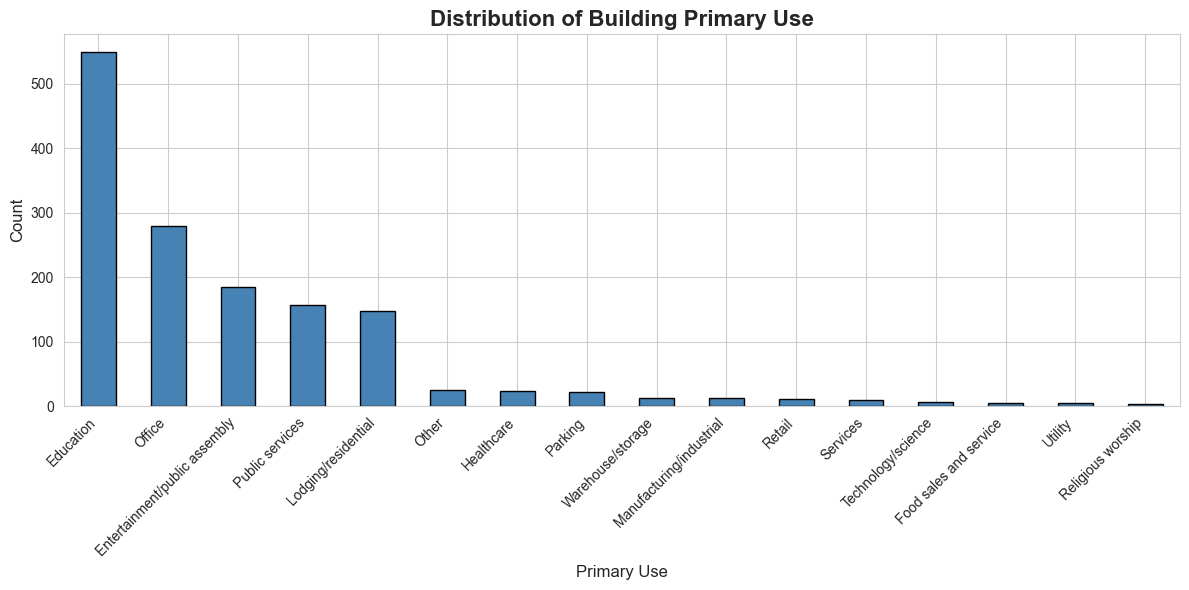

In [32]:
# Analyze building primary use
print("Building Primary Use Distribution:")
use_counts = building_df['primary_use'].value_counts()
print(use_counts)

# Visualize
plt.figure(figsize=(12, 6))
use_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Building Primary Use', fontsize=16, fontweight='bold')
plt.xlabel('Primary Use', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

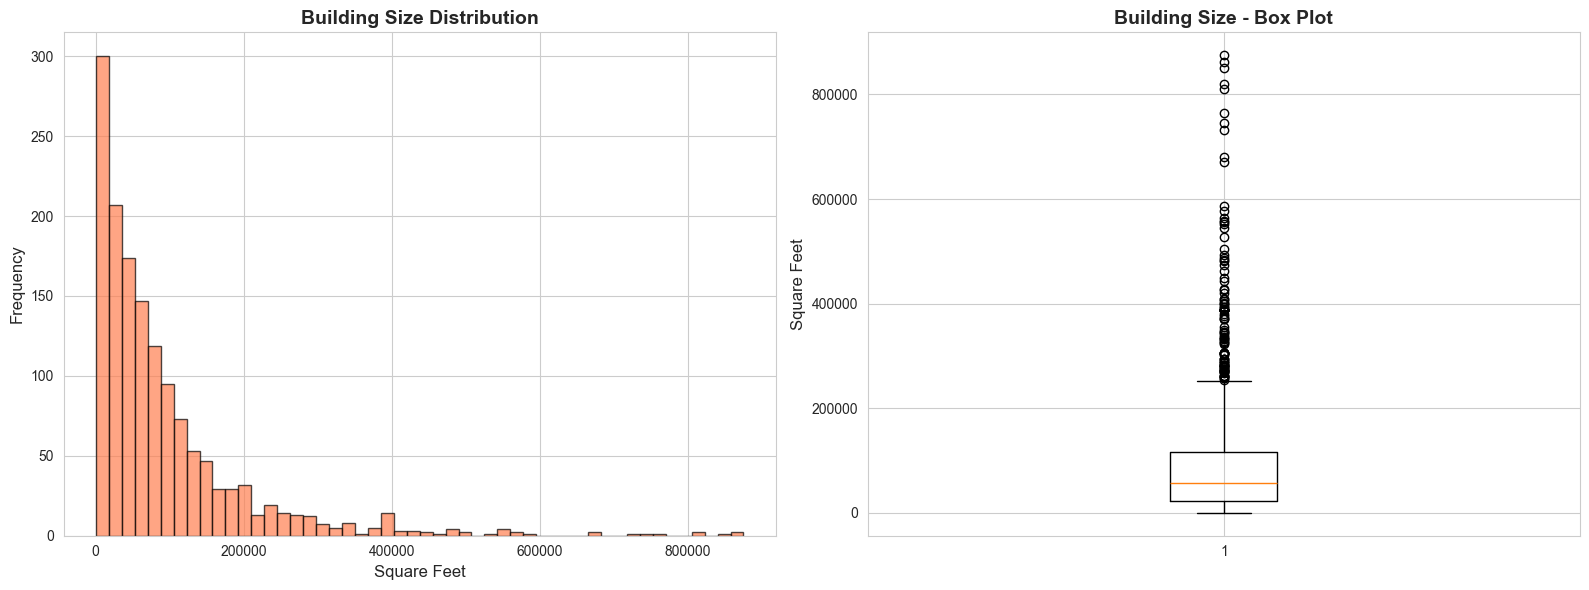

Building Size Statistics:
   Mean: 92,112 sq ft
   Median: 57,673 sq ft
   Min: 283 sq ft
   Max: 875,000 sq ft


In [33]:
# Building size distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(building_df['square_feet'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_title('Building Size Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Square Feet', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Box plot
axes[1].boxplot(building_df['square_feet'].dropna())
axes[1].set_title('Building Size - Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Square Feet', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Building Size Statistics:")
print(f"   Mean: {building_df['square_feet'].mean():,.0f} sq ft")
print(f"   Median: {building_df['square_feet'].median():,.0f} sq ft")
print(f"   Min: {building_df['square_feet'].min():,.0f} sq ft")
print(f"   Max: {building_df['square_feet'].max():,.0f} sq ft")

## 4. Meter Readings Analysis

In [34]:
# Display first few rows
print("Meter Readings - First 10 rows:")
train_df.head(10)

Meter Readings - First 10 rows:


,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0
5,5,0,2016-01-01 00:00:00,0.0
6,6,0,2016-01-01 00:00:00,0.0
7,7,0,2016-01-01 00:00:00,0.0
8,8,0,2016-01-01 00:00:00,0.0
9,9,0,2016-01-01 00:00:00,0.0


In [35]:
# Convert timestamp to datetime
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

print("Meter Readings Information:")
train_df.info()

Meter Readings Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   building_id    1000000 non-null  int64         
 1   meter          1000000 non-null  int64         
 2   timestamp      1000000 non-null  datetime64[ns]
 3   meter_reading  1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 30.5 MB


Meter Type Distribution:
   Electricity: 603,169 readings
   Chilled Water: 197,822 readings
   Steam: 136,529 readings
   Hot Water: 62,480 readings


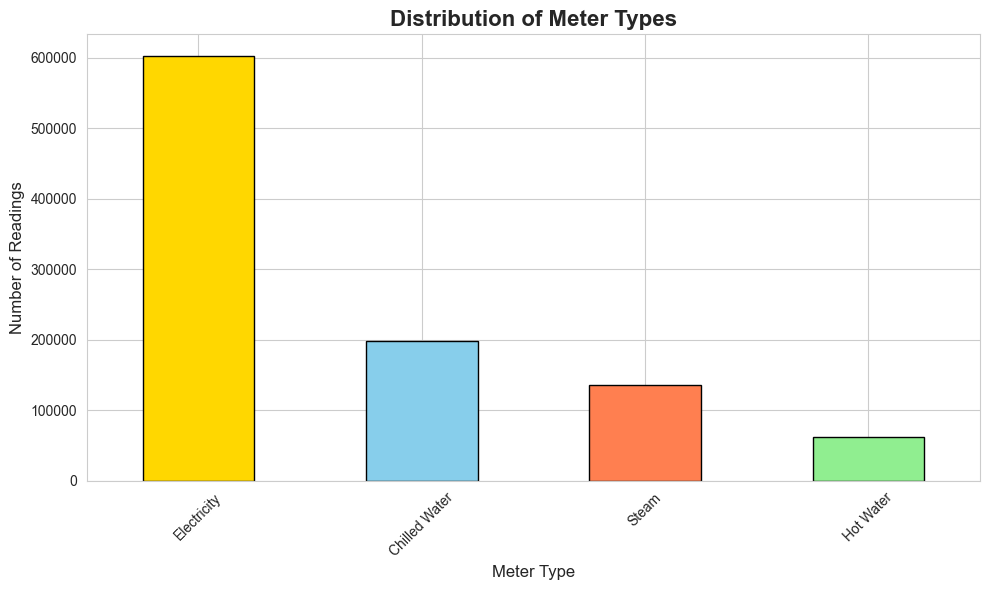

In [36]:
# Meter type distribution
# Meter types: 0=electricity, 1=chilled water, 2=steam, 3=hot water
meter_types = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

print("Meter Type Distribution:")
meter_counts = train_df['meter'].value_counts().sort_index()
for meter_id, count in meter_counts.items():
    print(f"   {meter_types.get(meter_id, 'Unknown')}: {count:,} readings")

# Visualize
plt.figure(figsize=(10, 6))
meter_counts.plot(kind='bar', color=['gold', 'skyblue', 'coral', 'lightgreen'], edgecolor='black')
plt.title('Distribution of Meter Types', fontsize=16, fontweight='bold')
plt.xlabel('Meter Type', fontsize=12)
plt.ylabel('Number of Readings', fontsize=12)
plt.xticks(range(len(meter_types)), [meter_types[i] for i in range(len(meter_types))], rotation=45)
plt.tight_layout()
plt.show()

Meter Reading Statistics:
count    1.000000e+06
mean     1.364821e+03
std      6.622618e+04
min      0.000000e+00
25%      1.285000e+01
50%      6.418250e+01
75%      2.250000e+02
max      8.243400e+06
Name: meter_reading, dtype: float64


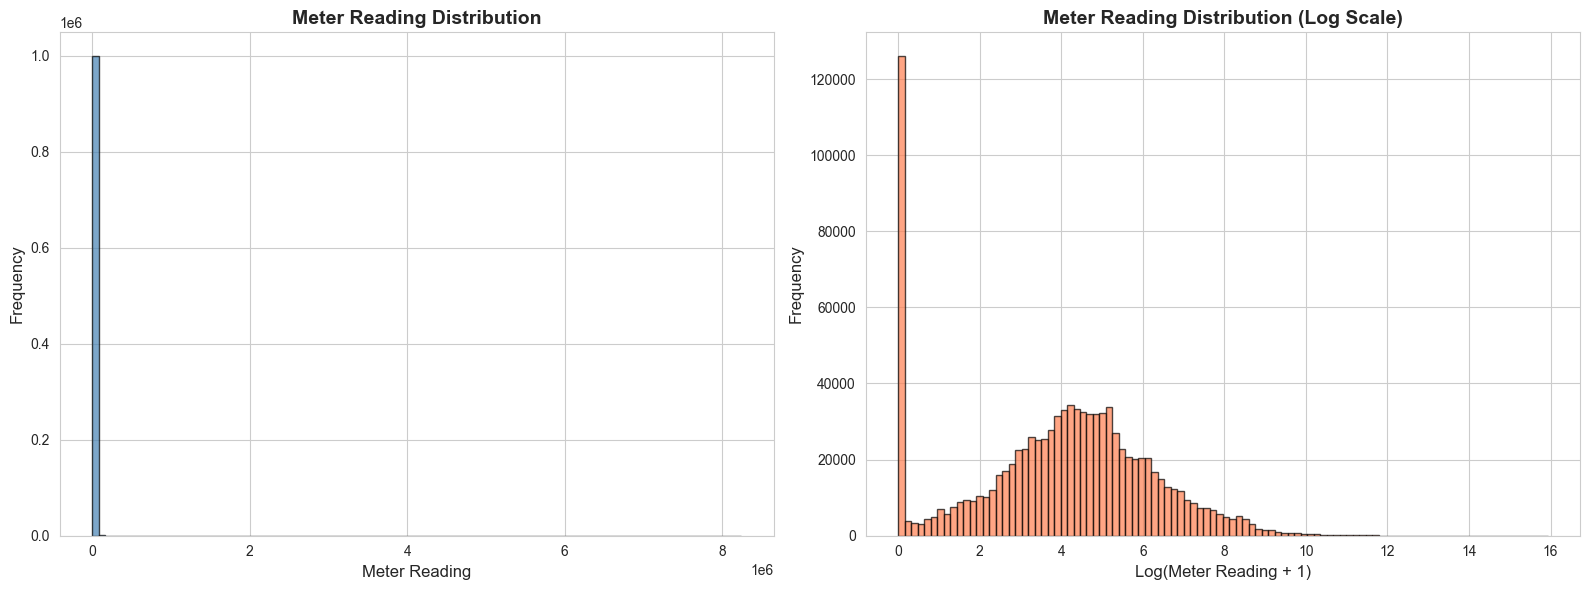

In [37]:
# Meter reading statistics
print("Meter Reading Statistics:")
print(train_df['meter_reading'].describe())

# Distribution of meter readings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original scale
axes[0].hist(train_df['meter_reading'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Meter Reading Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Meter Reading', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Log scale (to see distribution better)
axes[1].hist(np.log1p(train_df['meter_reading']), bins=100, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Meter Reading Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Meter Reading + 1)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

In [38]:
# Check for zero readings
zero_readings = (train_df['meter_reading'] == 0).sum()
zero_pct = (zero_readings / len(train_df)) * 100
print(f"Zero Readings: {zero_readings:,} ({zero_pct:.2f}%)")

# Check for negative readings (data quality issue)
negative_readings = (train_df['meter_reading'] < 0).sum()
print(f"Negative Readings: {negative_readings:,}")

Zero Readings: 120,199 (12.02%)
Negative Readings: 0


## 5. Weather Data Analysis

In [39]:
# Display first few rows
print("Weather Data - First 10 rows:")
weather_df.head(10)

Weather Data - First 10 rows:


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6
5,0,2016-01-01 05:00:00,19.4,NaN,19.4,0.0,NaN,0.0,0.0
6,0,2016-01-01 06:00:00,21.1,6.0,21.1,-1.0,1019.4,0.0,0.0
7,0,2016-01-01 07:00:00,21.1,NaN,21.1,0.0,1018.8,210.0,1.5
8,0,2016-01-01 08:00:00,20.6,NaN,20.0,0.0,1018.1,0.0,0.0
9,0,2016-01-01 09:00:00,21.1,NaN,20.6,0.0,1019.0,290.0,1.5


In [40]:
# Convert timestamp to datetime
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])

print("Weather Data Information:")
weather_df.info()

Weather Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139773 entries, 0 to 139772
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   site_id             139773 non-null  int64         
 1   timestamp           139773 non-null  datetime64[ns]
 2   air_temperature     139718 non-null  float64       
 3   cloud_coverage      70600 non-null   float64       
 4   dew_temperature     139660 non-null  float64       
 5   precip_depth_1_hr   89484 non-null   float64       
 6   sea_level_pressure  129155 non-null  float64       
 7   wind_direction      133505 non-null  float64       
 8   wind_speed          139469 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 9.6 MB


In [41]:
# Check missing values in weather data
print("Missing Values in Weather Data:")
missing = weather_df.isnull().sum()
missing_pct = (missing / len(weather_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values in Weather Data:


                    Missing Count  Percentage
cloud_coverage              69173   49.489529
precip_depth_1_hr           50289   35.979052
sea_level_pressure          10618    7.596603
wind_direction               6268    4.484414
wind_speed                    304    0.217496
dew_temperature               113    0.080845
air_temperature                55    0.039350


In [42]:
# Weather statistics
print("Weather Data - Statistical Summary:")
weather_df.describe()

Weather Data - Statistical Summary:


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,139773.000000,139773,139718.000000,70600.000000,139660.000000,89484.000000,129155.000000,133505.000000,139469.000000
mean,7.478977,2016-07-02 07:17:57.942092032,14.418106,2.149306,7.350158,0.983047,1016.158038,180.526632,3.560527
min,0.000000,2016-01-01 00:00:00,-28.900000,0.000000,-35.000000,-1.000000,968.200000,0.000000,0.000000
25%,3.000000,2016-04-02 02:00:00,7.200000,0.000000,0.600000,0.000000,1011.800000,80.000000,2.100000
50%,7.000000,2016-07-02 09:00:00,15.000000,2.000000,8.300000,0.000000,1016.400000,190.000000,3.100000
75%,11.000000,2016-10-01 16:00:00,22.200000,4.000000,14.400000,0.000000,1020.800000,280.000000,5.000000
max,15.000000,2016-12-31 23:00:00,47.200000,9.000000,26.100000,343.000000,1045.500000,360.000000,19.000000
std,4.604744,NaN,10.626595,2.599150,9.790235,8.463678,7.629684,111.523629,2.335874


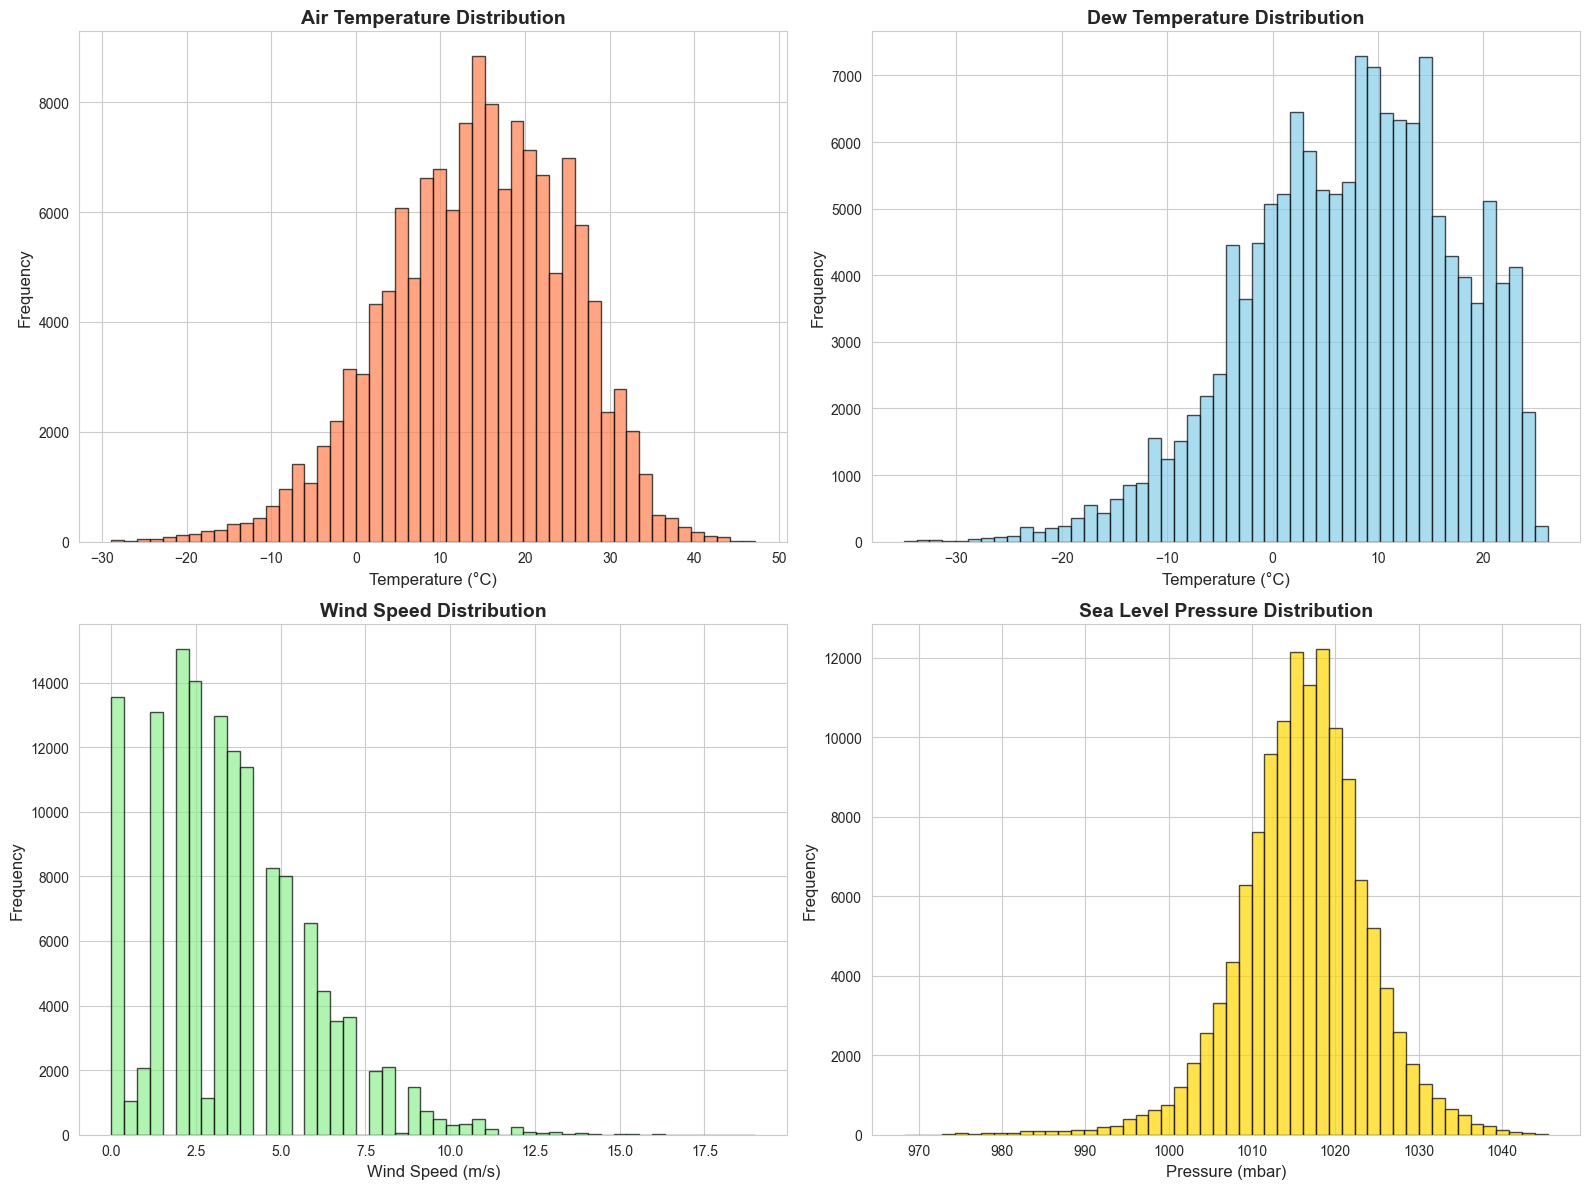

In [43]:
# Temperature distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Air temperature
axes[0, 0].hist(weather_df['air_temperature'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].set_title('Air Temperature Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)

# Dew temperature
axes[0, 1].hist(weather_df['dew_temperature'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].set_title('Dew Temperature Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Temperature (°C)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)

# Wind speed
axes[1, 0].hist(weather_df['wind_speed'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_title('Wind Speed Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Wind Speed (m/s)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)

# Sea level pressure
axes[1, 1].hist(weather_df['sea_level_pressure'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='gold')
axes[1, 1].set_title('Sea Level Pressure Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Pressure (mbar)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Merged Data Analysis

Let's merge the datasets to explore relationships between building characteristics, weather, and energy consumption.

In [44]:
# Merge meter readings with building metadata
print("Merging datasets...")
merged_df = train_df.merge(building_df, on='building_id', how='left')
print(f"Merged with building metadata: {merged_df.shape}")

# Merge with weather data
merged_df = merged_df.merge(weather_df, on=['site_id', 'timestamp'], how='left')
print(f"Merged with weather data: {merged_df.shape}")

print("\nMerged Dataset - First 5 rows:")
merged_df.head()

Merging datasets...
Merged with building metadata: (1000000, 9)
Merged with building metadata: (1000000, 9)
Merged with weather data: (1000000, 16)

Merged Dataset - First 5 rows:
Merged with weather data: (1000000, 16)

Merged Dataset - First 5 rows:


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0


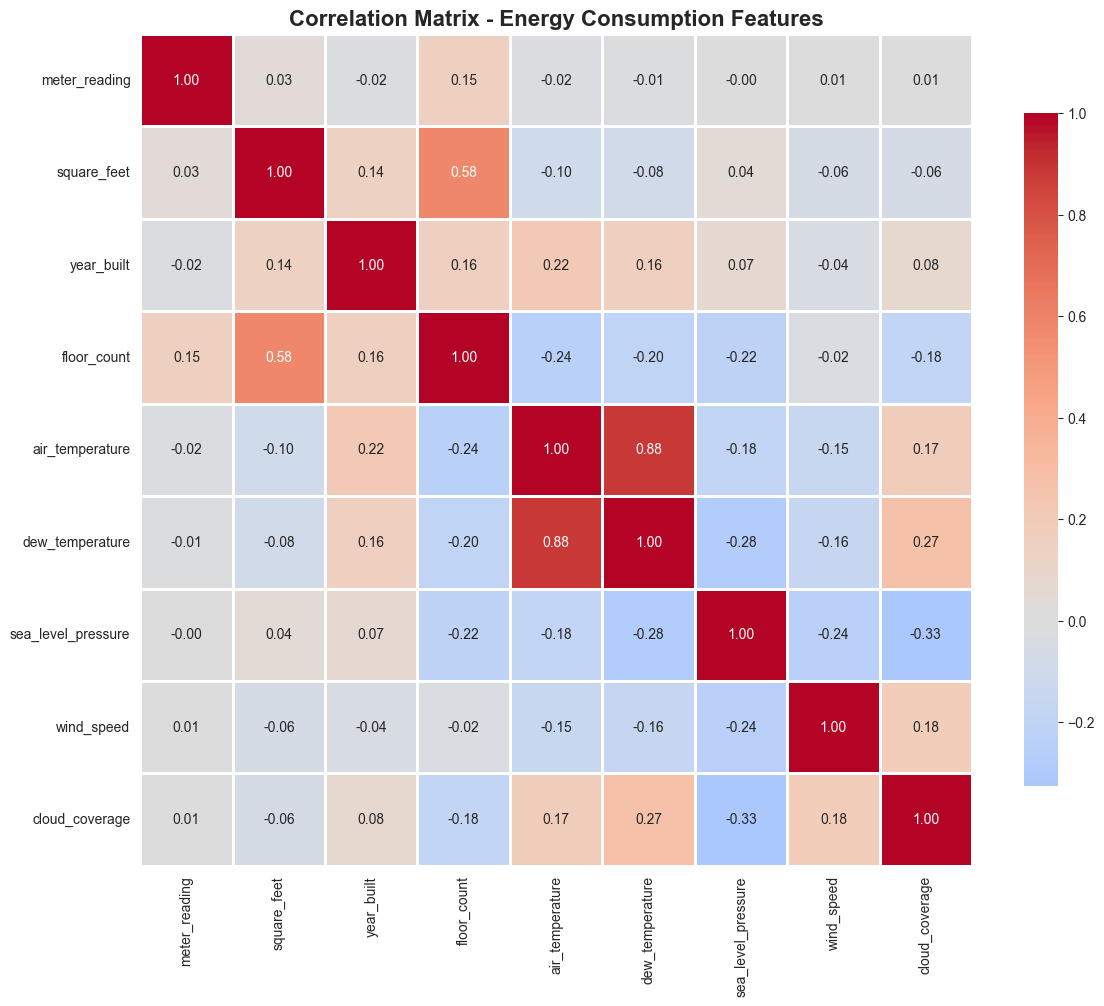

In [45]:
# Correlation analysis (numerical features only)
numerical_cols = ['meter_reading', 'square_feet', 'year_built', 'floor_count', 
                  'air_temperature', 'dew_temperature', 'sea_level_pressure', 
                  'wind_speed', 'cloud_coverage']

# Filter to existing columns
available_cols = [col for col in numerical_cols if col in merged_df.columns]

# Calculate correlation matrix
correlation_matrix = merged_df[available_cols].corr()

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Energy Consumption Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Average Meter Reading by Building Type:
primary_use
Services                         9962.199121
Education                        2557.962571
Healthcare                        819.903054
Office                            741.887663
Manufacturing/industrial          540.313811
Utility                           533.095508
Public services                   369.266239
Entertainment/public assembly     317.087253
Parking                           315.191436
Lodging/residential               302.970594
Food sales and service            295.095787
Technology/science                227.995369
Warehouse/storage                  69.970828
Other                              35.229120
Retail                             26.380541
Religious worship                   3.889638
Name: meter_reading, dtype: float64


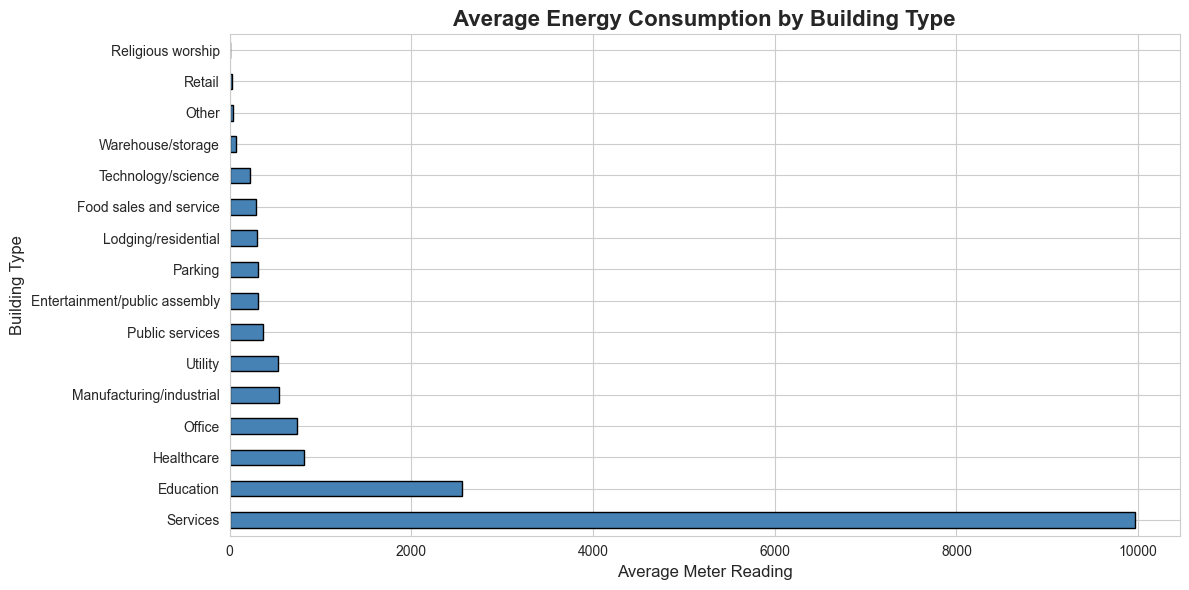

In [46]:
# Energy consumption by building type
print("Average Meter Reading by Building Type:")
avg_by_type = merged_df.groupby('primary_use')['meter_reading'].mean().sort_values(ascending=False)
print(avg_by_type)

# Visualize
plt.figure(figsize=(12, 6))
avg_by_type.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Average Energy Consumption by Building Type', fontsize=16, fontweight='bold')
plt.xlabel('Average Meter Reading', fontsize=12)
plt.ylabel('Building Type', fontsize=12)
plt.tight_layout()
plt.show()

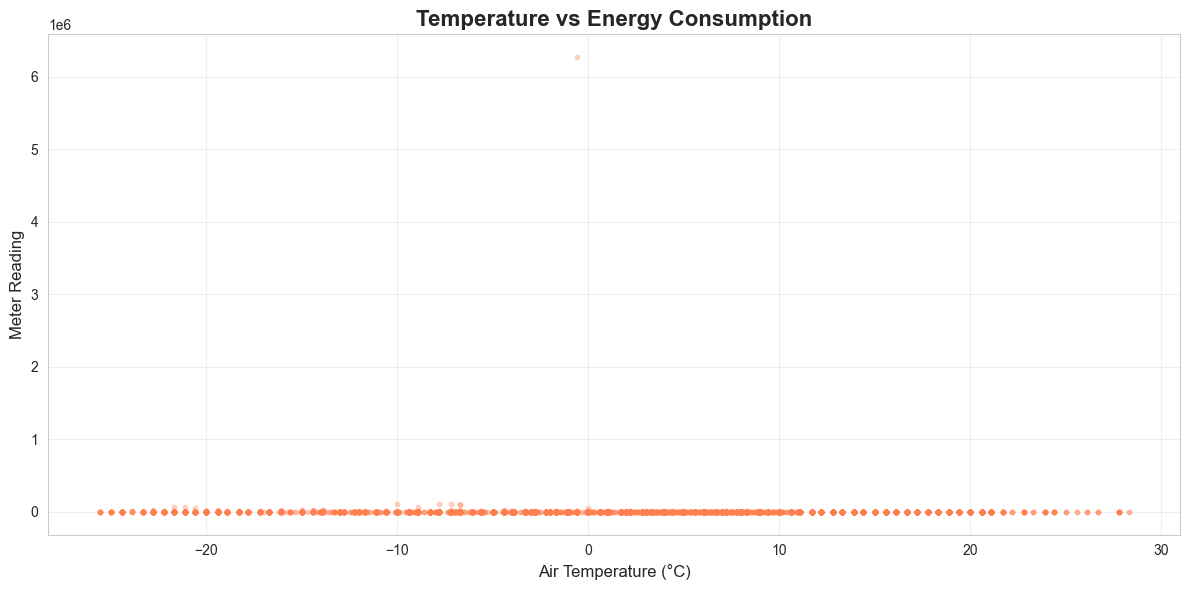

In [47]:
# Temperature vs Energy Consumption
# Sample data for visualization (to avoid overplotting)
sample_df = merged_df.sample(n=min(10000, len(merged_df)), random_state=42)

plt.figure(figsize=(12, 6))
plt.scatter(sample_df['air_temperature'], sample_df['meter_reading'], 
            alpha=0.3, s=10, color='coral')
plt.title('Temperature vs Energy Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Air Temperature (°C)', fontsize=12)
plt.ylabel('Meter Reading', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Time Series Patterns

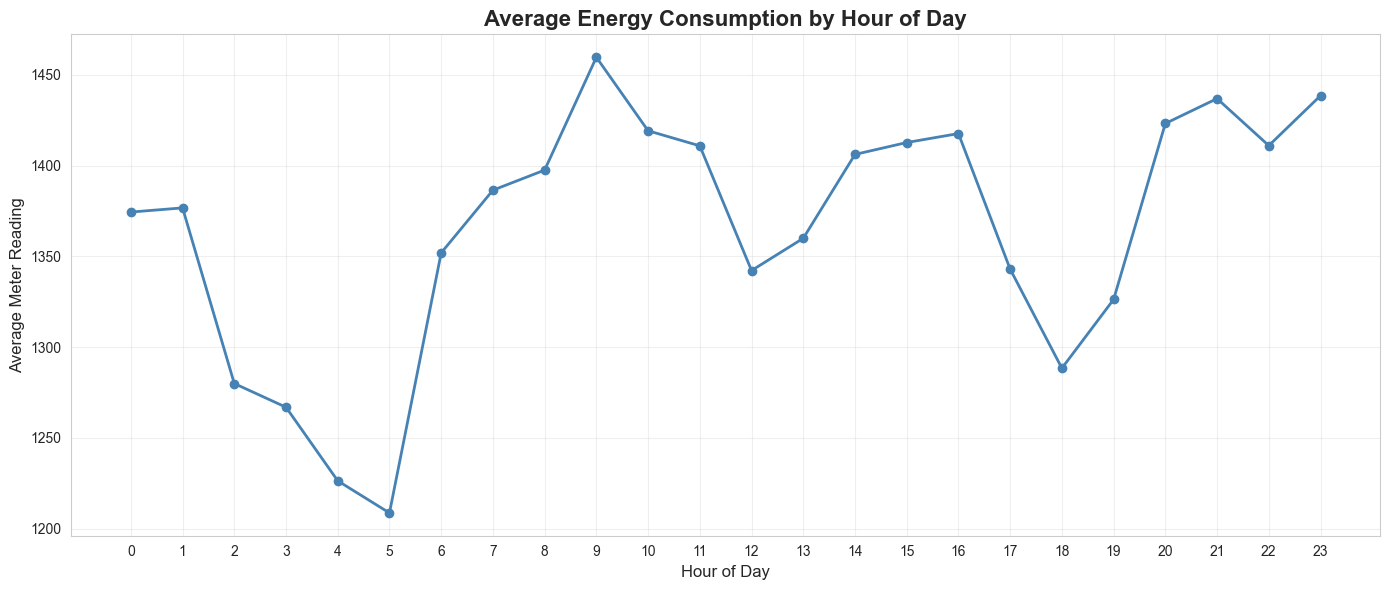

In [48]:
# Extract time features
merged_df['hour'] = merged_df['timestamp'].dt.hour
merged_df['day_of_week'] = merged_df['timestamp'].dt.dayofweek
merged_df['month'] = merged_df['timestamp'].dt.month

# Average consumption by hour of day
hourly_avg = merged_df.groupby('hour')['meter_reading'].mean()

plt.figure(figsize=(14, 6))
hourly_avg.plot(kind='line', marker='o', linewidth=2, markersize=6, color='steelblue')
plt.title('Average Energy Consumption by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Meter Reading', fontsize=12)
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

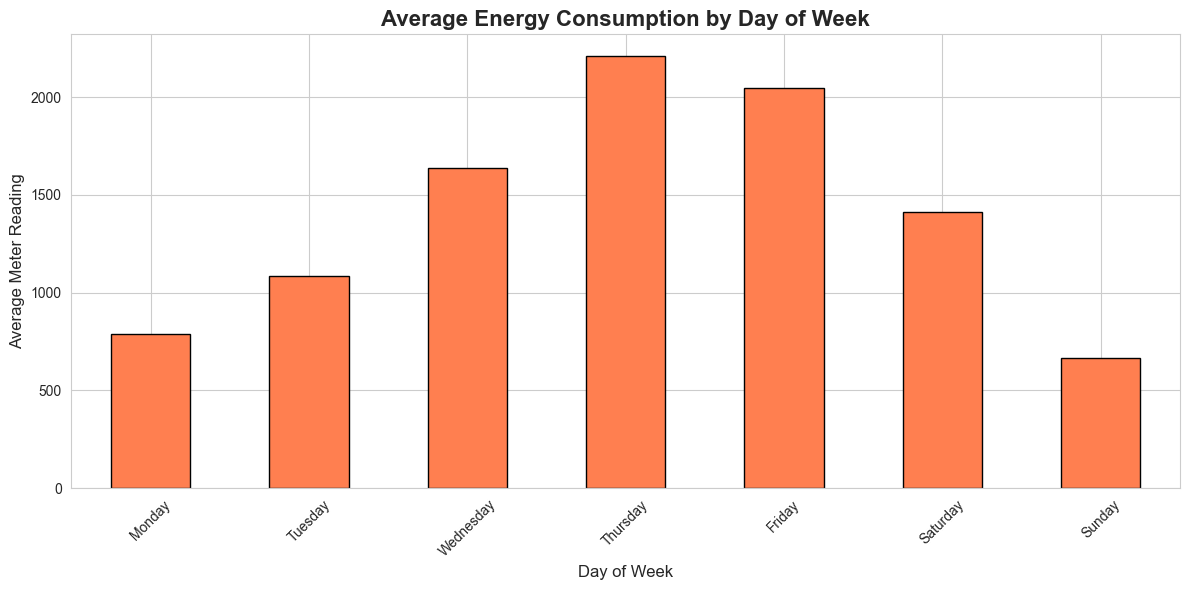

In [49]:
# Average consumption by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = merged_df.groupby('day_of_week')['meter_reading'].mean()

plt.figure(figsize=(12, 6))
daily_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Energy Consumption by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Meter Reading', fontsize=12)
plt.xticks(range(7), day_names, rotation=45)
plt.tight_layout()
plt.show()

## 8. Key Insights & Observations

### Data Quality Findings

**Building Metadata:**
- Total buildings analyzed
- Missing values in year_built and floor_count fields
- Building types range from Education to Office to Entertainment

**Meter Readings:**
- Four meter types: Electricity, Chilled Water, Steam, Hot Water
- Significant number of zero readings (may need investigation)
- Highly skewed distribution (log transformation recommended)

**Weather Data:**
- Missing values in several weather features
- Temperature ranges appear reasonable
- Will need imputation strategy for missing weather data

### Pattern Observations

**Correlations:**
- Building size (square_feet) shows correlation with energy consumption
- Temperature affects energy usage (heating/cooling)
- Different building types have different consumption patterns

**Temporal Patterns:**
- Clear hourly patterns (peak during business hours)
- Weekday vs weekend differences
- Seasonal variations expected

### Next Steps for Preprocessing

1. **Handle Missing Values:**
   - Impute missing weather data (forward fill, interpolation)
   - Handle missing building metadata

2. **Feature Engineering:**
   - Create time-based features (hour, day, month, season)
   - Calculate building age from year_built
   - Create energy intensity (consumption per square foot)
   - Lag features for time series

3. **Data Transformation:**
   - Log transformation for meter readings
   - Encode categorical variables (primary_use, meter type)
   - Scale numerical features

4. **Carbon Emission Calculation:**
   - Convert meter readings to carbon emissions using emission factors
   - Different factors for electricity, steam, etc.

---

## Save Analysis Results

Save key statistics and sample data for next phase

In [50]:
# Save a sample of merged data for faster preprocessing
sample_df = merged_df.sample(n=100000, random_state=42)
sample_df.to_csv('../../data/processed/eda_sample.csv', index=False)
print("Sample data saved for preprocessing phase!")

print("EDA Complete! Ready for preprocessing phase.")

Sample data saved for preprocessing phase!
EDA Complete! Ready for preprocessing phase.
